## Analysis of an E-commerce Dataset Part 2

The goal of the second analysis task is to train linear regression models to predict users' ratings towards items. This involves a standard Data Science workflow: exploring data, building models, making predictions, and evaluating results. In this task, we will explore the impacts of feature selections and different sizes of training/testing data on the model performance. We will use another cleaned combined e-commerce sub-dataset that **is different from** the one in “Analysis of an E-commerce Dataset” task 1.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import r2_score
from sklearn.preprocessing import OrdinalEncoder

import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline

### Import Cleaned E-commerce Dataset
The csv file named 'cleaned_ecommerce_dataset.csv' is provided. You may need to use the Pandas method, i.e., `read_csv`, for reading it. After that, please print out its total length.

In [2]:
#reading the dataset
df=pd.read_csv('cleaned_ecommerce_dataset.csv')
df

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
0,4081,71900,Not always McCrap,McDonald's,4.0,3.0,M,Restaurants & Gourmet,41,30.74,4
1,4081,72000,I dropped the chalupa even before he told me to,Taco Bell,1.0,4.0,M,Restaurants & Gourmet,74,108.30,4
2,4081,72000,The Wonderful World of Wendy,Wendy's,5.0,4.0,M,Restaurants & Gourmet,84,69.00,4
3,4081,100399,They actually did it,"South Park: Bigger, Longer & Uncut",5.0,3.0,M,Movies,68,143.11,4
4,4081,100399,Hey! Gimme some pie!,American Pie,3.0,3.0,M,Movies,6,117.89,4
...,...,...,...,...,...,...,...,...,...,...,...
2680,2445,22000,Great movie!,Austin Powers: The Spy Who Shagged Me,5.0,3.0,M,Movies,9,111.00,5
2681,2445,30700,Good food!,Outback Steakhouse,5.0,3.0,M,Restaurants & Gourmet,50,25.00,5
2682,2445,61500,Great movie!,Fight Club,5.0,3.0,M,Movies,26,97.53,5
2683,2445,100500,Awesome Game.,The Sims 2: Open for Business for Windows,5.0,4.0,M,Games,79,27.00,5


In [3]:
data_length = len(df)
print("Total length:",data_length)

Total length: 2685


### Explore the Dataset

* Use the methods, i.e., `head()` and `info()`, to have a rough picture about the data, e.g., how many columns, and the data types of each column.
* As our goal is to predict ratings given other columns, please get the correlations between helpfulness/gender/category/review and rating by using the `corr()` method.

  Hints: To get the correlations between different features, you may need to first convert the categorical features (i.e., gender, category and review) into numerial values. For doing this, you may need to import `OrdinalEncoder` from `sklearn.preprocessing` (refer to the useful exmaples [here](https://pbpython.com/categorical-encoding.html))
* Please provide ___necessary explanations/analysis___ on the correlations, and figure out which are the ___most___ and ___least___ corrleated features regarding rating. Try to ___discuss___ how the correlation will affect the final prediction results, if we use these features to train a regression model for rating prediction. In what follows, we will conduct experiments to verify your hypothesis.

In [4]:
df.head()

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
0,4081,71900,Not always McCrap,McDonald's,4.0,3.0,M,Restaurants & Gourmet,41,30.74,4
1,4081,72000,I dropped the chalupa even before he told me to,Taco Bell,1.0,4.0,M,Restaurants & Gourmet,74,108.30,4
2,4081,72000,The Wonderful World of Wendy,Wendy's,5.0,4.0,M,Restaurants & Gourmet,84,69.00,4
3,4081,100399,They actually did it,"South Park: Bigger, Longer & Uncut",5.0,3.0,M,Movies,68,143.11,4
4,4081,100399,Hey! Gimme some pie!,American Pie,3.0,3.0,M,Movies,6,117.89,4


In [5]:
#convert from numerical to categorical
enc = OrdinalEncoder() 
df[["review", "gender", "category"]] = enc.fit_transform(df[["review", "gender", "category"]])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2685 entries, 0 to 2684
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   userId       2685 non-null   int64  
 1   timestamp    2685 non-null   int64  
 2   review       2685 non-null   float64
 3   item         2685 non-null   object 
 4   rating       2685 non-null   float64
 5   helpfulness  2685 non-null   float64
 6   gender       2685 non-null   float64
 7   category     2685 non-null   float64
 8   item_id      2685 non-null   int64  
 9   item_price   2685 non-null   float64
 10  user_city    2685 non-null   int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 230.9+ KB


In [7]:
#display the correlation between helpfulness, gender, category, review, rating
correl = df[['helpfulness', 'gender', 'category', 'review', 'rating']].corr()
print(correl)

             helpfulness    gender  category    review    rating
helpfulness     1.000000  0.075947 -0.013408 -0.028259 -0.007523
gender          0.075947  1.000000  0.022549 -0.037884 -0.034337
category       -0.013408  0.022549  1.000000  0.001970 -0.163158
review         -0.028259 -0.037884  0.001970  1.000000 -0.036118
rating         -0.007523 -0.034337 -0.163158 -0.036118  1.000000


In [ ]:
#ANALYSIS
#The most correlated feature regarding rating is category, while the least correlated is heplfulness. Due to the weak 
#correlations between rating and the other features, the MSE and root MSE are likely to be high. This would suggest that
#the model is not observing data patterns and may not be a suitable predictor

### Split Training and Testing Data
* Machine learning models are trained to help make predictions for the future. Normally, we need to randomly split the dataset into training and testing sets, where we use the training set to train the model, and then leverage the well-trained model to make predictions on the testing set.
* To further investigate whether the size of the training/testing data affects the model performance, please random split the data into training and testing sets with different sizes:
    * Case 1: training data containing 10% of the entire data;
    * Case 2: training data containing 90% of the entire data.
* Print the shape of training and testing sets in the two cases.

In [9]:
#training data containing 10% of the data
train_1, test_1 = train_test_split(df, test_size=0.1, random_state=142)
print(train_1.shape)
print(test_1.shape)

(2416, 11)
(269, 11)


In [10]:
#training data containing 90% of the data
train_2, test_2 = train_test_split(df, test_size=0.9, random_state=142)
print(train_2.shape)
print(test_2.shape)

(268, 11)
(2417, 11)


### Train Linear Regression Models with Feature Selection under Cases 1 & 2
* When training a machine learning model for prediction, we may need to select the most important/correlated input features for more accurate results.
* To investigate whether feature selection affects the model performance, please select two most correlated features and two least correlated features from helpfulness/gender/category/review regarding rating, respectively.
* Train four linear regression models by following the conditions:
    - (model-a) using the training/testing data in case 1 with two most correlated input features
    - (model-b) using the training/testing data in case 1 with two least correlated input features
    - (model-c) using the training/testing data in case 2 with two most correlated input features
    - (model-d) using the training/testing data in case 2 with two least correlated input features
* By doing this, we can verify the impacts of the size of traing/testing data on the model performance via comparing model-a and model-c (or model-b and model-d); meanwhile the impacts of feature selection can be validated via comparing model-a and model-b (or model-c and model-d).    

In [98]:
#model a - case 1 againt two most correlated
reg_1 = linear_model.LinearRegression()
X_train_1= train_1[['category', 'review']]
y_train_1 = train_1['rating']

X_test_1= test_1[['category', 'review']]
y_test_1 = test_1['rating']

reg_1.fit(X_train_1, y_train_1)

LinearRegression()

In [99]:
#model b - case 1 againt two least correlated
reg_2 = linear_model.LinearRegression()
X_train_2= train_1[['helpfulness', 'gender']]
y_train_2 = train_1['rating']

X_test_2= test_1[['helpfulness', 'gender']]
y_test_2 = test_1['rating']

reg_2.fit(X_train_2, y_train_2)

LinearRegression()

In [100]:
#model c - case 2 againt two most correlated
reg_3 = linear_model.LinearRegression()
X_train_3= train_2[['category', 'review']]
y_train_3 = train_2['rating']

X_test_3= test_2[['category', 'review']]
y_test_3 = test_2['rating']

reg_3.fit(X_train_3, y_train_3)

LinearRegression()

In [101]:
#model d - case 2 againt two least correlated
reg_4 = linear_model.LinearRegression()
X_train_4= train_2[['helpfulness', 'gender']]
y_train_4 = train_2['rating']

X_test_4= test_2[['helpfulness', 'gender']]
y_test_4 = test_2['rating']

reg_4.fit(X_train_4, y_train_4)

LinearRegression()

### Evaluate Models
* Evaluate the performance of the four models with two metrics, including MSE and Root MSE
* Print the results of the four models regarding the two metrics

In [102]:
#model a
predicted_1 = reg_1.predict(X_test_1)
mse_1 = ((np.array(y_test_1)-predicted_1)**2).sum()/len(y_test_1)
rmse_1 = np.sqrt(mse_1)
print("MSE:", mse_1)
print("Root MSE:", rmse_1)

MSE: 1.758897535980505
Root MSE: 1.3262343442923294


In [103]:
#model b
predicted_2 = reg_2.predict(X_test_2)
mse_2 = ((np.array(y_test_2)-predicted_2)**2).sum()/len(y_test_2)
rmse_2 = np.sqrt(mse_2)
print("MSE:", mse_2)
print("Root MSE:", rmse_2)

MSE: 1.8109460127732366
Root MSE: 1.3457139416581954


In [104]:
#model c
predicted_3 = reg_3.predict(X_test_3)
mse_3 = ((np.array(y_test_3)-predicted_3)**2).sum()/len(y_test_3)
rmse_3 = np.sqrt(mse_3)
print("MSE:", mse_3)
print("Root MSE:", rmse_3)

MSE: 1.7690740179517055
Root MSE: 1.3300654186737229


In [105]:
#model d
predicted_4 = reg_4.predict(X_test_4)
mse_4 = ((np.array(y_test_4)-predicted_4)**2).sum()/len(y_test_4)
rmse_4 = np.sqrt(mse_4)
print("MSE:", mse_4)
print("Root MSE:", rmse_4)

MSE: 1.8412549895856636
Root MSE: 1.356928513071217


### Visualize, Compare and Analyze the Results
* Visulize the results, and perform ___insightful analysis___ on the obtained results. For better visualization, you may need to carefully set the scale for the y-axis.
* Normally, the model trained with most correlated features and more training data will get better results. Do you obtain the similar observations? If not, please ___explain the possible reasons___.

Text(0, 0.5, 'Predictions')

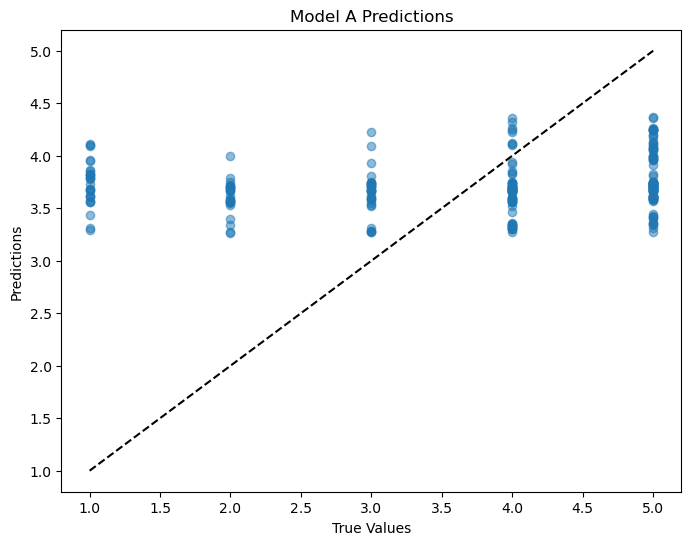

In [106]:
plt.figure(figsize=(8, 6))
plt.subplot(1, 1, 1)
plt.scatter(y_test_1, reg_1.predict(X_test_1), alpha=0.5)
plt.plot([min(y_test_1), max(y_test_1)], [min(y_test_1), max(y_test_1)], '--k')
plt.title('Model A Predictions')
plt.xlabel('True Values')
plt.ylabel('Predictions')

In [ ]:
#ANALYSIS
#Predictions are consistently not in line with the perfect predictions line. This may mean model may not be predicting 
#sufficiently. True values 1 and 5 are quite spread out, portraying higher variance from the model's predictions. 
#True values 2 and 4 are less spread out. #As the features (category and reviews) are weakly correlated, 
#the scatter in the plot is quite spread out. However comparing this model to others, there is a stronger correlation which 
#supports the hypothesis" the model trained with most correlated features and more training data will get better results."


(2.5, 4.5)

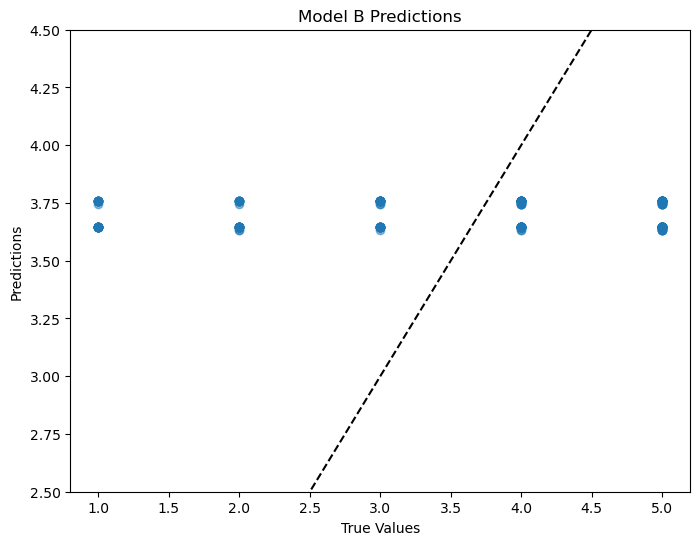

In [117]:
plt.figure(figsize=(8, 6))
plt.subplot(1, 1, 1)
plt.scatter(y_test_2, reg_2.predict(X_test_2), alpha=0.5)
plt.plot([min(y_test_2), max(y_test_2)], [min(y_test_2), max(y_test_2)], '--k')
plt.title(f'Model B Predictions')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.ylim(2.5,4.5)

In [118]:
#ANALYSIS
#There is a very narrow range of values all situating between 3.5 and 4. The model also does not display a visible trend nor
#correlation. The scaled y-axis shows that there is little to no variance in the predictions. Model B may not be useful to
#utilise for making predictions.Hence, the two least correlated features with rating (gender and helpfulness) show little to 
#no variance and are quite offset from the perfect prediction line.This may be due to the features originally being 
#categorical and not numerical. They may not have distinct values being categorical which may affect the model's performance.

Text(0, 0.5, 'Predictions')

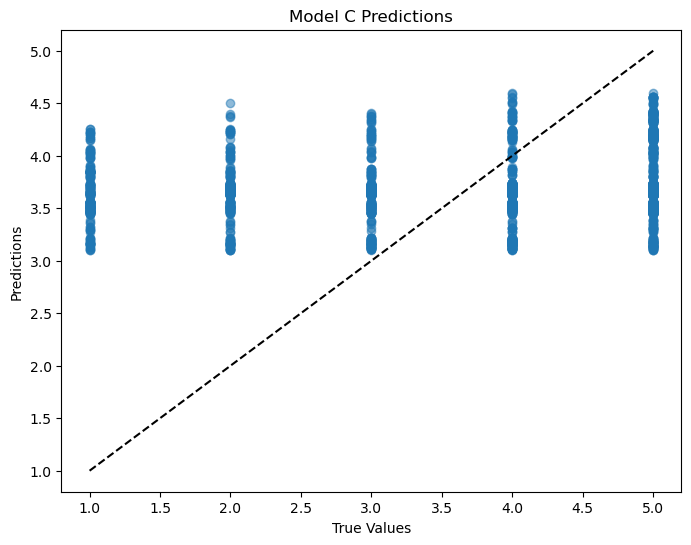

In [119]:
plt.figure(figsize=(8, 6))
plt.subplot(1, 1, 1)
plt.scatter(y_test_3, reg_3.predict(X_test_3), alpha=0.5)
plt.plot([min(y_test_3), max(y_test_3)], [min(y_test_3), max(y_test_3)], '--k')
plt.title('Model C Predictions')
plt.xlabel('True Values')
plt.ylabel('Predictions')


In [ ]:
#ANALYSIS
#Model C shows a wide range of predictions. The clustering of predictions (vertically) shows that there is quite a large 
#variance in each of the true values that have been predicted. This high variance could imply that while the model is trying
#to take in the differences in true values, they are still not precise. The true value predictions of 1 and 5 are tightly 
#clustered in comparison to the other predictions. This may imply that the model may predict smaller numbers and bigger 
#numbers more accurately, respectfully.This model is predicting using the higher correlated features, and is achieving better 
#results. This argues for the hypothesis in the question "the model trained with most correlated features and more training
#data will get better results"

(2.0, 5.0)

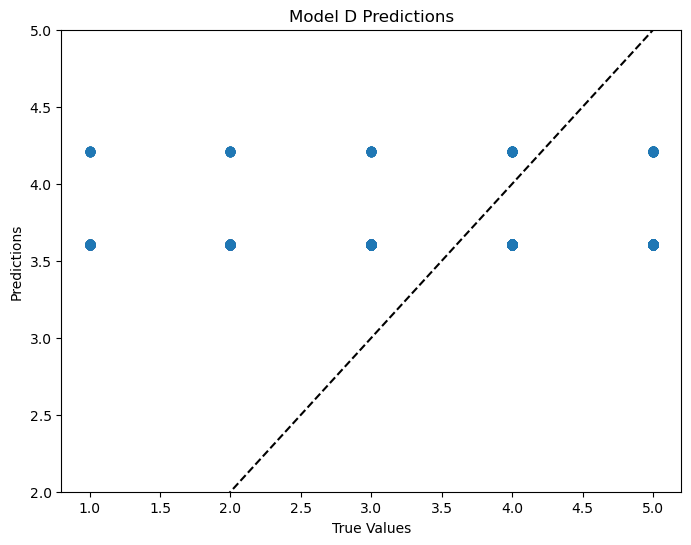

In [128]:
plt.figure(figsize=(8, 6))
plt.subplot(1, 1, 1)
plt.scatter(y_test_4, reg_4.predict(X_test_4), alpha=0.5)
plt.plot([min(y_test_4), max(y_test_4)], [min(y_test_4), max(y_test_4)], '--k')
plt.title('Model D Predictions')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.ylim(2,5)

In [126]:
#ANALYSIS
#The predictions in Model D are quite tightly clustered, also showing less variance compared to Models A and C. 
#This might imply that the model is more assured in the predictions. This model in fact shows the two least correlated features,
#supporting the arguement in the quetion "the model trained with most correlated features and more training data will get 
#better results", as there is a weaker correlation displayed.

### Data Science Ethics
*Please read the following examples [Click here to read the example_1.](https://www.vox.com/covid-19-coronavirus-us-response-trump/2020/5/18/21262265/georgia-covid-19-cases-declining-reopening) [Click here to read the example_2.](https://viborc.com/ethics-and-ethical-data-visualization-a-complete-guide/)

*Then view the picture ![My Image](figure_portfolio2.png "This is my image")
Please compose an analysis of 100-200 words that evaluates potential ethical concerns associated with the infographic, detailing the reasons behind these issues.


In [ ]:
#Countries are grouped into two tables: total medals and gold medals. This can provide a variety of success tales.
#It can also contribute to the perception that some nations are more successful than others, without taking into 
#consideration aspects such as the number of athletes competing, the number of events included, 
#or the availability of training resources. The data can also be misused and taken out of context to bias and promote a particular
#agenda or story. Furthermore, a ranking based on total medals earned against gold medals may reflect a hierarchy of medal
#value, undervaluing the efforts of lesser-known silver and bronze medalists.